# Forward and backward Euler on the test ODE

Companion notebook for Section 3.2 of `Lec3.tex`. Solves the test ODE
$$
\frac{du}{dt} = \lambda u, \qquad u(0) = c, \qquad t > 0,
$$
with the forward Euler method
$$
u_{n+1} = u_n + \lambda u_n \, \delta t = (1 + \lambda \delta t) u_n,
$$
and the backward Euler method, which for this linear right-hand side can be solved explicitly for $u_{n+1}$,
$$
u_{n+1} = u_n + \lambda u_{n+1} \, \delta t \quad \Longrightarrow \quad u_{n+1} = \frac{u_n}{1 - \lambda \delta t}.
$$
Both are compared against the exact solution $u(t) = c e^{\lambda t}$.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [39]:
# parameters (lambda may be complex, as allowed in the test ODE (3.3))
delta_t = 2.2
lam = -0.8 + 0.2j

# initial condition and time interval
c = 1.0 + 0.0j
T = 10.0

N = int(round(T / delta_t))
t = np.arange(N + 1) * delta_t

In [40]:
def forward_euler_test_ode(c, lam, delta_t, N):
    u = np.empty(N + 1, dtype=complex)
    u[0] = c
    for n in range(N):
        u[n + 1] = u[n] + lam * u[n] * delta_t
    return u


def backward_euler_test_ode(c, lam, delta_t, N):
    u = np.empty(N + 1, dtype=complex)
    u[0] = c
    for n in range(N):
        u[n + 1] = u[n] / (1 - lam * delta_t)
    return u

In [41]:
u_fe = forward_euler_test_ode(c, lam, delta_t, N)
u_be = backward_euler_test_ode(c, lam, delta_t, N)
u_exact = c * np.exp(lam * t)

print(f"lambda = {lam}, delta_t = {delta_t}")
print(f"forward Euler amplification factor |1 + lambda*dt|  = {abs(1 + lam * delta_t):.3f}")
print(f"backward Euler amplification factor |1/(1-lambda*dt)| = {abs(1 / (1 - lam * delta_t)):.3f}")

lambda = (-0.8+0.2j), delta_t = 2.2
forward Euler amplification factor |1 + lambda*dt|  = 0.878
backward Euler amplification factor |1/(1-lambda*dt)| = 0.358


saved test_ode_euler_dt2.2.png


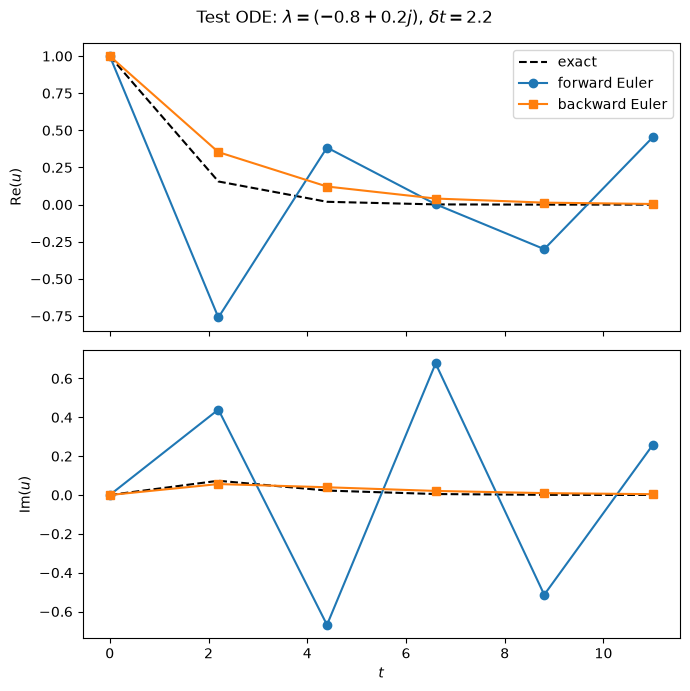

In [42]:
fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True)

axes[0].plot(t, u_exact.real, "k--", label="exact")
axes[0].plot(t, u_fe.real, "o-", label="forward Euler")
axes[0].plot(t, u_be.real, "s-", label="backward Euler")
axes[0].set_ylabel(r"$\mathrm{Re}(u)$")
axes[0].legend()

axes[1].plot(t, u_exact.imag, "k--", label="exact")
axes[1].plot(t, u_fe.imag, "o-", label="forward Euler")
axes[1].plot(t, u_be.imag, "s-", label="backward Euler")
axes[1].set_xlabel("$t$")
axes[1].set_ylabel(r"$\mathrm{Im}(u)$")

fig.suptitle(rf"Test ODE: $\lambda={lam}$, $\delta t={delta_t}$")
fig.tight_layout()

filename = f"test_ode_euler_dt{delta_t:g}.png"
fig.savefig(filename, dpi=300, bbox_inches="tight")
print(f"saved {filename}")
plt.show()